# REST APIs — Final Project
## European Weather Dashboard
Combining Open-Meteo and OpenWeatherMap APIs to build an interactive weather dashboard with Plotly.

In [1]:
import requests
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("OPENWEATHER_API_KEY")

print("Setup complete. API key loaded:", api_key is not None)

Setup complete. API key loaded: True


In [2]:
cities = [
    {"name": "Barcelona", "country": "ES", "lat": 41.39, "lon": 2.15},
    {"name": "Madrid",    "country": "ES", "lat": 40.42, "lon": -3.70},
    {"name": "Lisbon",    "country": "PT", "lat": 38.72, "lon": -9.14},
    {"name": "Paris",     "country": "FR", "lat": 48.85, "lon": 2.35},
    {"name": "Berlin",    "country": "DE", "lat": 52.52, "lon": 13.40},
    {"name": "Amsterdam", "country": "NL", "lat": 52.37, "lon": 4.90},
]

print(f"{len(cities)} cities configured.")

6 cities configured.


In [3]:
def get_openweather(city: dict) -> dict:
    """Fetch current weather from OpenWeatherMap."""
    params = {
        "q": city["name"],
        "appid": api_key,
        "units": "metric"
    }
    response = requests.get("https://api.openweathermap.org/data/2.5/weather", params=params)
    response.raise_for_status()
    data = response.json()
    
    return {
        "city": city["name"],
        "temperature": data["main"]["temp"],
        "feels_like": data["main"]["feels_like"],
        "humidity": data["main"]["humidity"],
        "pressure": data["main"]["pressure"],
        "weather": data["weather"][0]["description"],
        "wind_speed": data["wind"]["speed"]
    }

def get_open_meteo(city: dict) -> dict:
    """Fetch current weather from Open-Meteo."""
    params = {
        "latitude": city["lat"],
        "longitude": city["lon"],
        "current_weather": True,
        "timezone": "Europe/Madrid"
    }
    response = requests.get("https://api.open-meteo.com/v1/forecast", params=params)
    response.raise_for_status()
    data = response.json()
    
    return {
        "city": city["name"],
        "temperature_meteo": data["current_weather"]["temperature"],
        "windspeed_meteo": data["current_weather"]["windspeed"]
    }

print("Functions defined.")

Functions defined.


In [4]:
import requests
response = requests.get("https://api.open-meteo.com/v1/forecast?latitude=41.39&longitude=2.15&current_weather=true", verify=False)
print(response.status_code)

200


C:\Users\apbal\miniconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.open-meteo.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [5]:
ow_records = []
meteo_records = []

for city in cities:
    try:
        ow_records.append(get_openweather(city))
        meteo_records.append(get_open_meteo(city))
        print(f"✓ {city['name']}")
    except Exception as e:
        print(f"✗ {city['name']} — {e}")

df_ow = pd.DataFrame(ow_records)
df_meteo = pd.DataFrame(meteo_records)

df = df_ow.merge(df_meteo, on="city")
df

✓ Barcelona
✓ Madrid
✓ Lisbon
✓ Paris
✓ Berlin
✓ Amsterdam


,city,temperature,feels_like,humidity,pressure,weather,wind_speed,temperature_meteo,windspeed_meteo
0,Barcelona,22.19,22.06,61,1016,overcast clouds,2.68,21.8,15.8
1,Madrid,25.25,24.80,37,1012,broken clouds,1.34,26.3,4.8
2,Lisbon,20.35,19.98,59,1018,scattered clouds,5.81,22.0,16.9
3,Paris,18.12,17.40,54,1016,overcast clouds,3.25,18.9,9.7
4,Berlin,21.36,20.96,54,1012,overcast clouds,5.36,20.9,13.6
5,Amsterdam,19.43,19.00,60,1013,broken clouds,4.02,19.5,16.6


In [6]:
ow_records = []
meteo_records = []

for city in cities:
    try:
        ow_records.append(get_openweather(city))
        meteo_records.append(get_open_meteo(city))
        print(f"✓ {city['name']}")
    except Exception as e:
        print(f"✗ {city['name']} — {e}")

df_ow = pd.DataFrame(ow_records)
df_meteo = pd.DataFrame(meteo_records)

df = df_ow.merge(df_meteo, on="city")
df

✓ Barcelona
✓ Madrid
✓ Lisbon
✓ Paris
✓ Berlin
✓ Amsterdam


,city,temperature,feels_like,humidity,pressure,weather,wind_speed,temperature_meteo,windspeed_meteo
0,Barcelona,22.19,22.06,61,1016,overcast clouds,2.68,21.8,15.8
1,Madrid,25.45,24.99,36,1012,broken clouds,1.34,26.3,4.8
2,Lisbon,20.35,19.98,59,1018,scattered clouds,5.81,22.0,16.9
3,Paris,18.12,17.40,54,1016,overcast clouds,3.25,18.9,9.7
4,Berlin,21.36,20.96,54,1012,overcast clouds,5.36,20.9,13.6
5,Amsterdam,19.43,19.00,60,1013,broken clouds,4.02,19.5,16.6


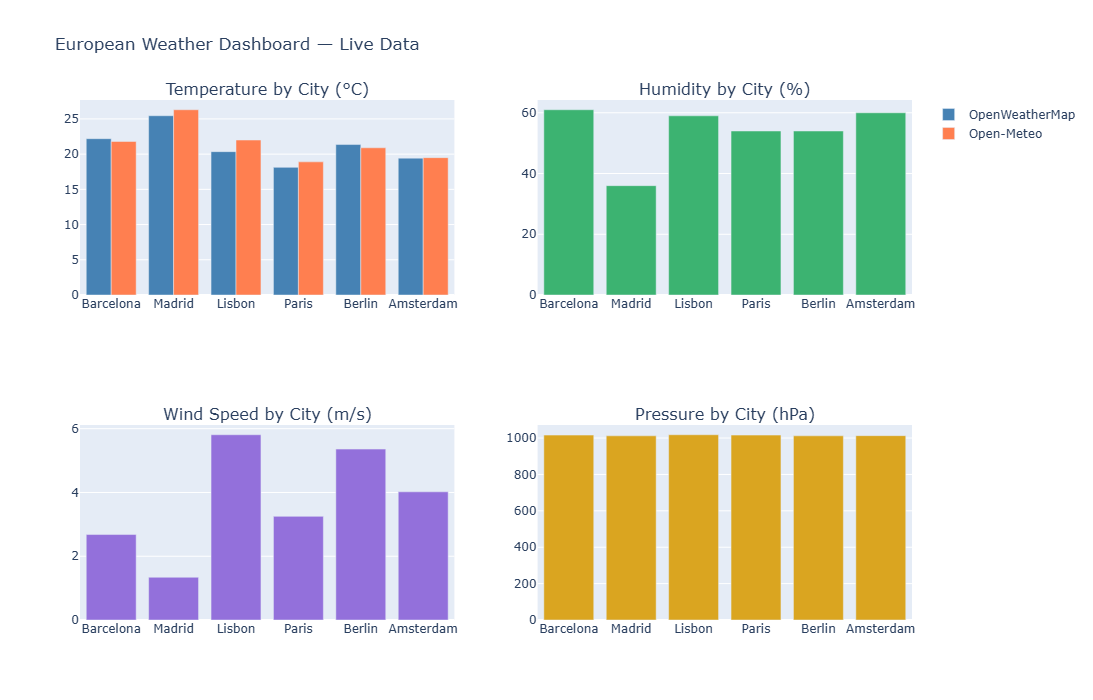

In [8]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=[
        'Temperature by City (°C)',
        'Humidity by City (%)',
        'Wind Speed by City (m/s)',
        'Pressure by City (hPa)'
    ])

# Temperature — comparing both APIs
fig.add_trace(go.Bar(name='OpenWeatherMap', x=df['city'], y=df['temperature'],
                     marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Bar(name='Open-Meteo', x=df['city'], y=df['temperature_meteo'],
                     marker_color='coral'), row=1, col=1)

# Humidity
fig.add_trace(go.Bar(name='Humidity', x=df['city'], y=df['humidity'],
                     marker_color='mediumseagreen', showlegend=False), row=1, col=2)

# Wind speed
fig.add_trace(go.Bar(name='Wind Speed', x=df['city'], y=df['wind_speed'],
                     marker_color='mediumpurple', showlegend=False), row=2, col=1)

# Pressure
fig.add_trace(go.Bar(name='Pressure', x=df['city'], y=df['pressure'],
                     marker_color='goldenrod', showlegend=False), row=2, col=2)

fig.update_layout(
    height=700,
    title_text='European Weather Dashboard — Live Data',
    barmode='group'
)

fig.show()

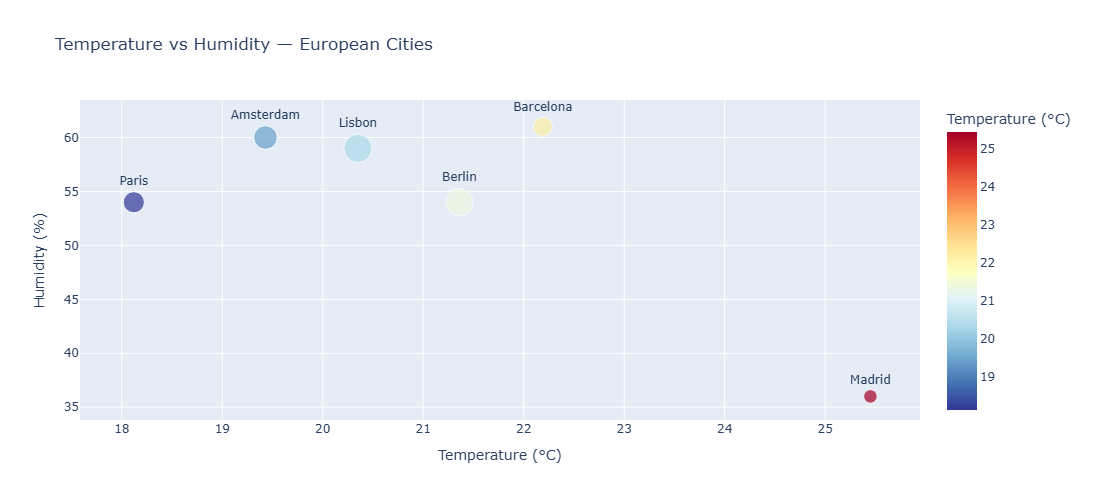

In [9]:
fig = px.scatter(
    df,
    x='temperature',
    y='humidity',
    text='city',
    size='wind_speed',
    color='temperature',
    color_continuous_scale='RdYlBu_r',
    title='Temperature vs Humidity — European Cities',
    labels={'temperature': 'Temperature (°C)', 'humidity': 'Humidity (%)'}
)

fig.update_traces(textposition='top center')
fig.update_layout(height=500)
fig.show()

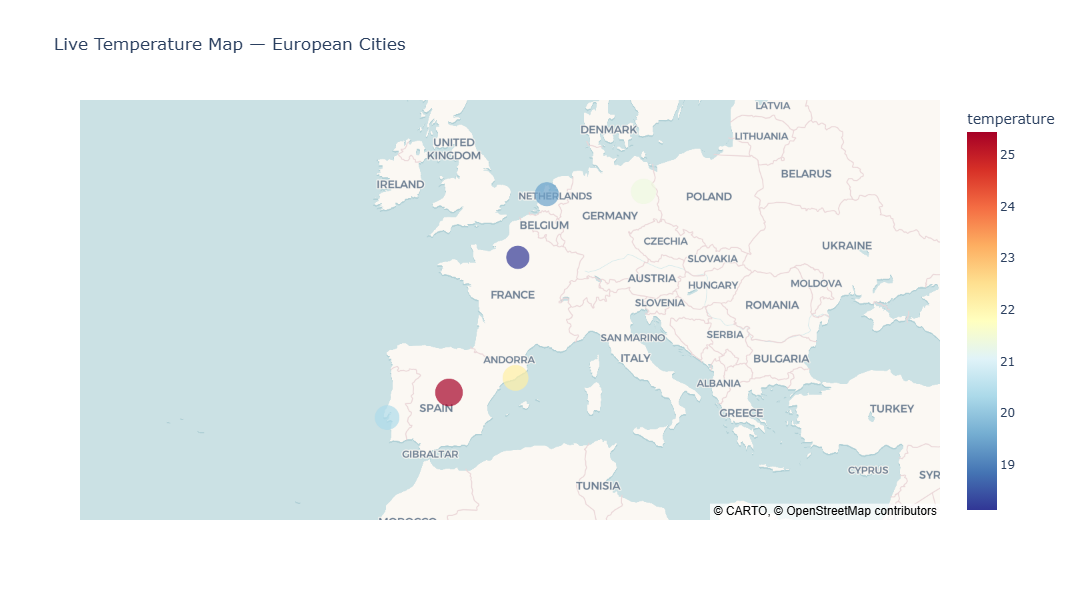

In [10]:
df['lat'] = [city['lat'] for city in cities]
df['lon'] = [city['lon'] for city in cities]

fig = px.scatter_map(
    df,
    lat='lat',
    lon='lon',
    size='temperature',
    color='temperature',
    hover_name='city',
    hover_data={'temperature': True, 'humidity': True, 'weather': True, 'lat': False, 'lon': False},
    color_continuous_scale='RdYlBu_r',
    title='Live Temperature Map — European Cities',
    zoom=3
)

fig.update_layout(height=600)
fig.show()